# Preprocesamiento de Datos - Detección de Outliers

Los **valores atípicos (outliers)** son puntos de datos que se alejan significativamente del resto de la muestra. Pueden ser errores de medición o valores extremos legítimos que afectan el rendimiento de los modelos de Machine Learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

# Cargamos los datos (Dataset Bupa - Enfermedades Hepáticas)
import sys
if 'google.colab' in sys.modules:
    data = pd.read_csv(f'https://raw.githubusercontent.com/dReposU/ML/main/Sem_2/bupa.csv', sep=';')
else:
    data = pd.read_csv("bupa.csv", sep=';')

data.head()

,V1,V2,V3,V4,V5,V6,V7
0,85,92,45,27,31,0.0,1
1,85,64,59,32,23,0.0,2
2,86,54,33,16,54,0.0,2
3,91,78,34,24,36,0.0,2
4,87,70,12,28,10,0.0,2


## 1. Prueba de Normalidad (Shapiro-Wilk)
Antes de usar la regla de los 3 sigmas (Z-score), debemos verificar si los datos siguen una distribución normal.

In [2]:
# Analizamos la variable V6
print(stats.shapiro(data['V6']))

# Interpretación:
# Si p-valor < 0.05 -> Los datos NO son normales.
# Si p-valor > 0.05 -> Los datos son normales.

ShapiroResult(statistic=np.float64(0.8354936513596574), pvalue=np.float64(1.6864816314857383e-18))


## 2. Regla de los 3 Sigmas (Detección de Outliers)
Esta regla establece que el 99.7% de los datos en una distribución normal caen dentro de 3 desviaciones estándar de la media.

In [3]:
media = data['V6'].mean()
desviacion = data['V6'].std()

# Cálculo de límites (Equivalente a Z-score de 3 y -3)
limite_superior = media + 3 * desviacion
limite_inferior = media - 3 * desviacion

print(f"Límite Superior: {limite_superior}")
print(f"Límite Inferior: {limite_inferior}")

# Identificamos los registros que están fuera de estos límites
outliers = data[(data['V6'] > limite_superior) | (data['V6'] < limite_inferior)]
print(f"Cantidad de outliers detectados: {len(outliers)}")

Límite Superior: 13.468578257499498
Límite Inferior: -6.558433329963267
Cantidad de outliers detectados: 5


## 3. Tratamiento de Outliers: Capping (Winsorización)
En lugar de eliminar los outliers, los limitamos a los valores extremos permitidos.

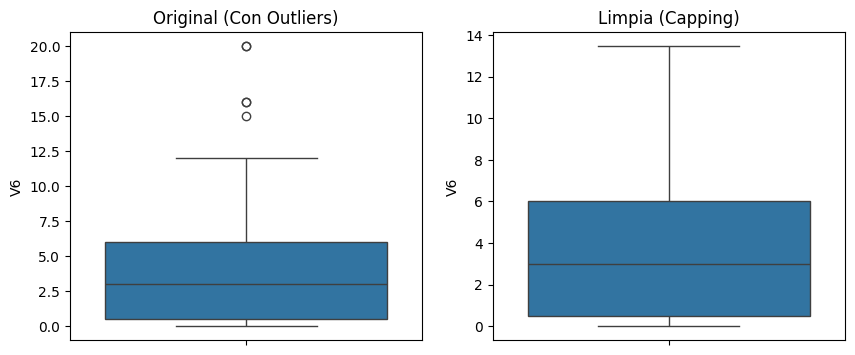

In [4]:
data_limpia = data.copy()

# Aplicamos el capping
data_limpia['V6'] = np.where(
    data_limpia['V6'] > limite_superior,
    limite_superior,
    np.where(data_limpia['V6'] < limite_inferior, limite_inferior, data_limpia['V6'])
)

# Verificamos visualmente
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=data['V6'])
plt.title('Original (Con Outliers)')

plt.subplot(1, 2, 2)
sns.boxplot(y=data_limpia['V6'])
plt.title('Limpia (Capping)')
plt.show()